# MNIST MLP3 baseline comparison

This notebook validates and compares the persisted three-seed **SGD + Nesterov**, **AdamW**, and **Muon + auxiliary AdamW** controls. It reads only from the versioned suite directory `mnist_mlp3_recipe_v3`; old unversioned 20-epoch artifacts are ignored.

All uncertainty intervals use complete training runs as the unit of replication. Validation loss selects the reported best checkpoint; the official MNIST test set is monitoring-only.


In [1]:
from pathlib import Path
import os
import sys

from IPython.display import display

ROOT = None
for path in [Path.cwd(), *Path.cwd().parents]:
    candidate = path / 'baseline'
    if (candidate / 'rg_baselines').is_dir():
        ROOT = candidate
        break
    if (path / 'rg_baselines').is_dir():
        ROOT = path
        break
if ROOT is None:
    raise RuntimeError('Run from a current clone of CalculatedContent/rg_optimizers.')
ROOT = ROOT.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from rg_baselines import (
    MNIST_REFERENCE_INITIALIZATION,
    MNIST_REFERENCE_RECIPE_VERSION,
    MNIST_REFERENCE_SUITE_SLUG,
)
from rg_baselines.comparison import OPTIMIZER_ORDER, run_baseline_comparison

BASE_RUN_ROOT = Path(
    os.environ.get('RG_BASELINE_RUN_ROOT', ROOT / 'runs')
).expanduser().resolve()
RUN_ROOT = BASE_RUN_ROOT / MNIST_REFERENCE_SUITE_SLUG
OUTPUT_DIR = RUN_ROOT / 'comparison'

legacy_directories = [
    BASE_RUN_ROOT / optimizer
    for optimizer in OPTIMIZER_ORDER
    if (BASE_RUN_ROOT / optimizer).is_dir()
]
if legacy_directories:
    print('Ignoring legacy unversioned result directories:')
    for directory in legacy_directories:
        print('  -', directory)

required_manifests = [
    RUN_ROOT / optimizer / 'replicate_manifest.json'
    for optimizer in OPTIMIZER_ORDER
]
missing = [path for path in required_manifests if not path.is_file()]
if missing:
    raise FileNotFoundError(
        'The current recipe-v3 baseline suite is incomplete. Run these '
        'three source notebooks first, in order:\n'
        '  1. MNIST_MLP3_SGD_Momentum_Baseline.ipynb\n'
        '  2. MNIST_MLP3_AdamW_Baseline.ipynb\n'
        '  3. MNIST_MLP3_SGD_Momentum_Muon_Baseline.ipynb\n'
        'Missing manifests:\n' + '\n'.join(f'  - {path}' for path in missing)
    )

print('MNIST reference recipe:', MNIST_REFERENCE_RECIPE_VERSION)
print('versioned suite root:', RUN_ROOT)


MNIST reference recipe: 3
versioned suite root: /private/tmp/rg_optimizers/baseline/notebooks/runs/mnist_mlp3_recipe_v3


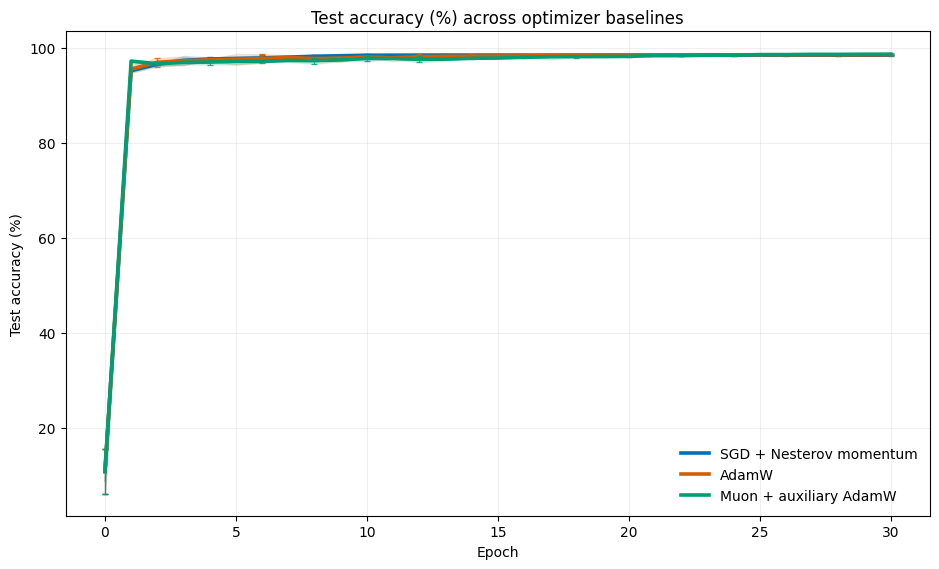

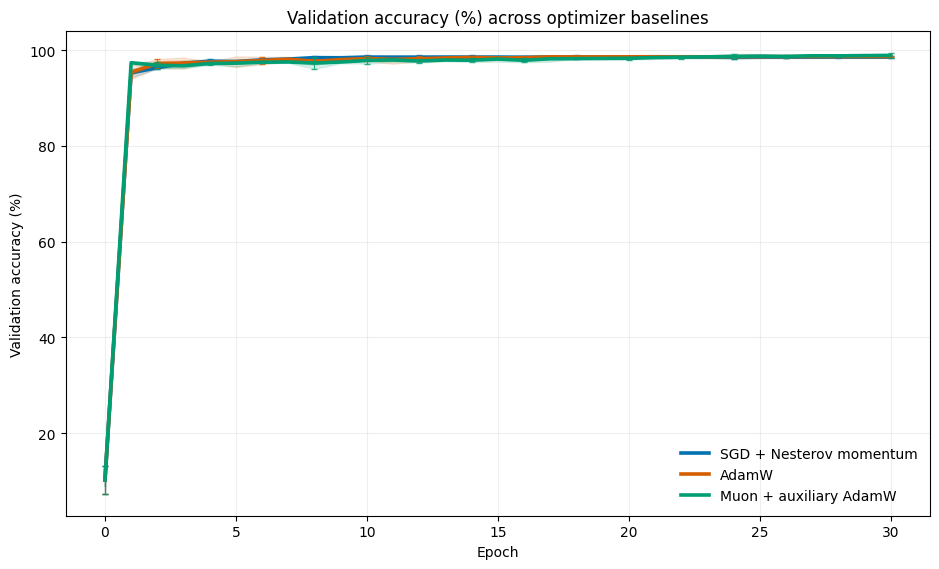

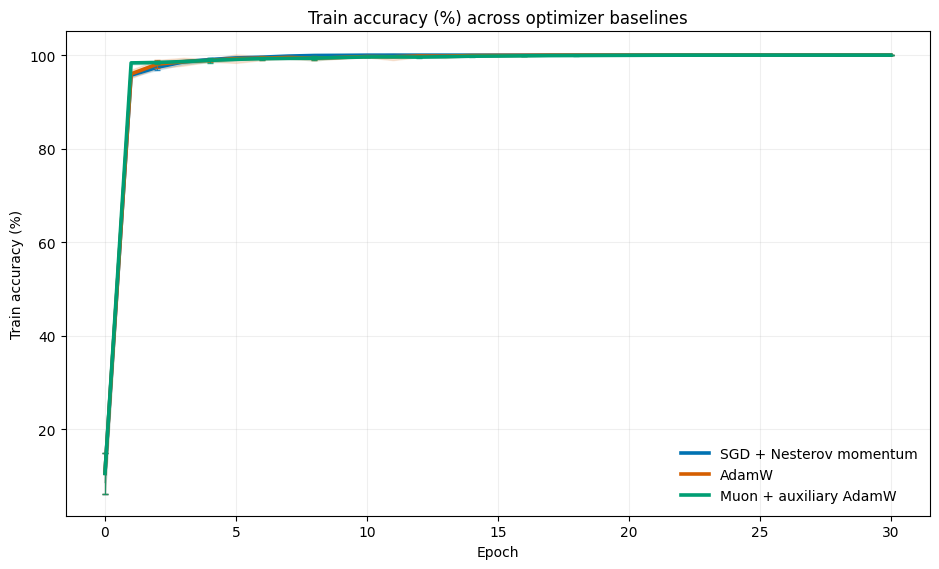

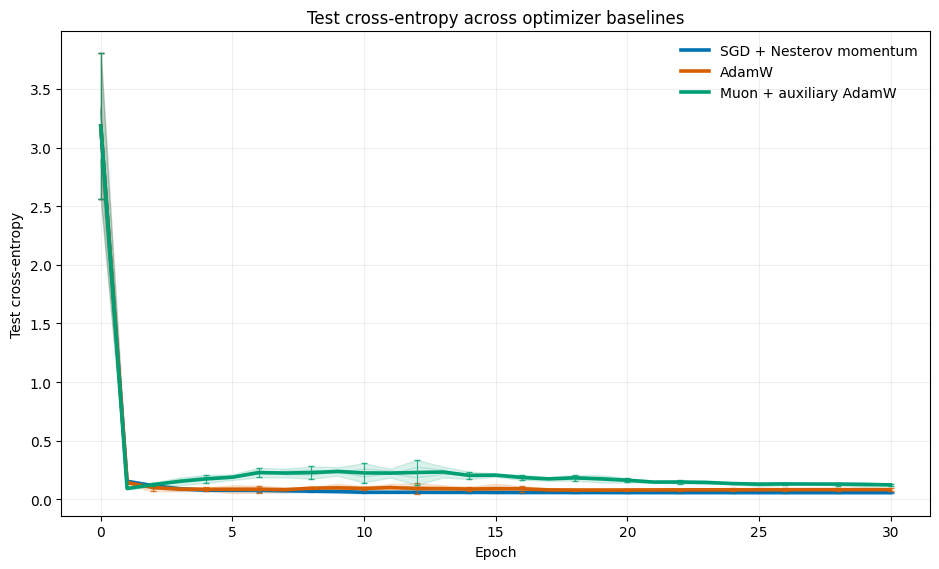

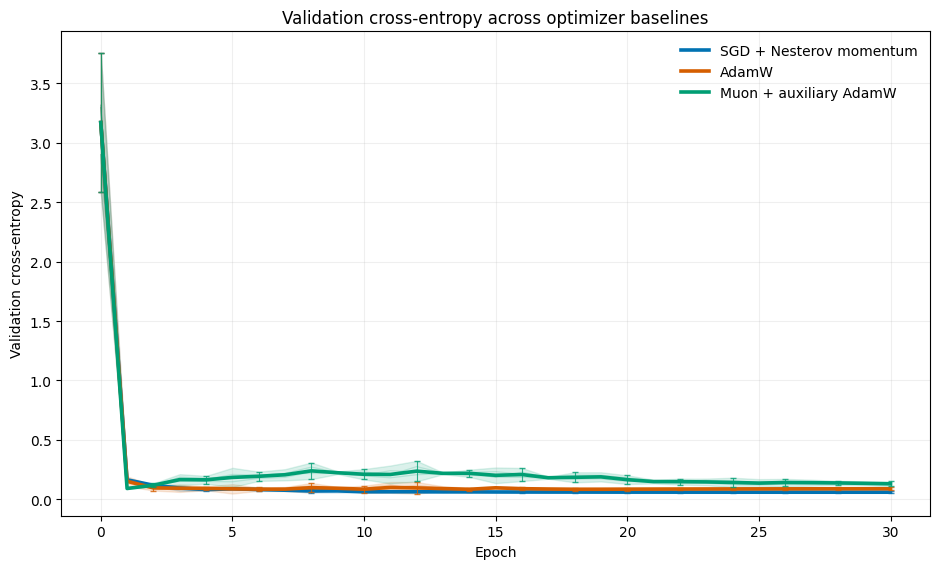

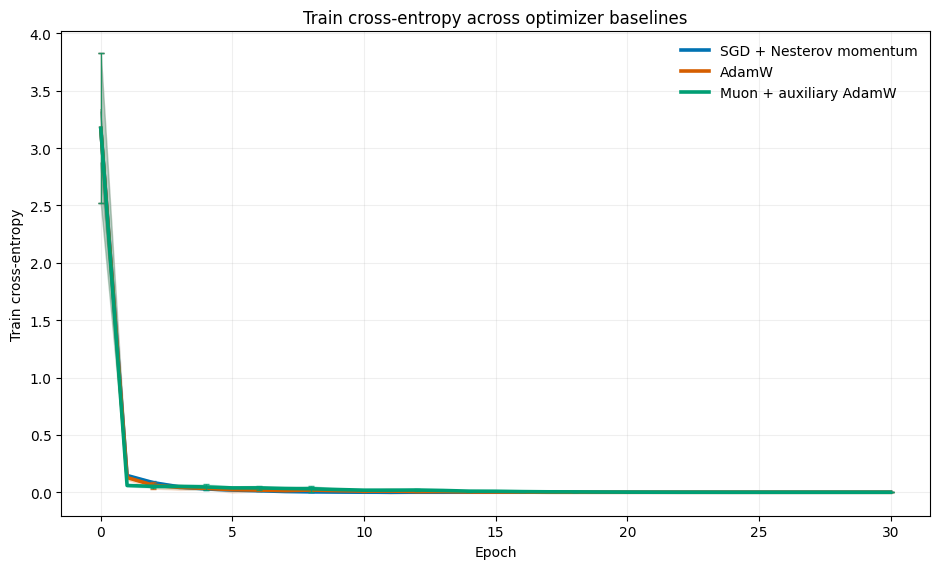

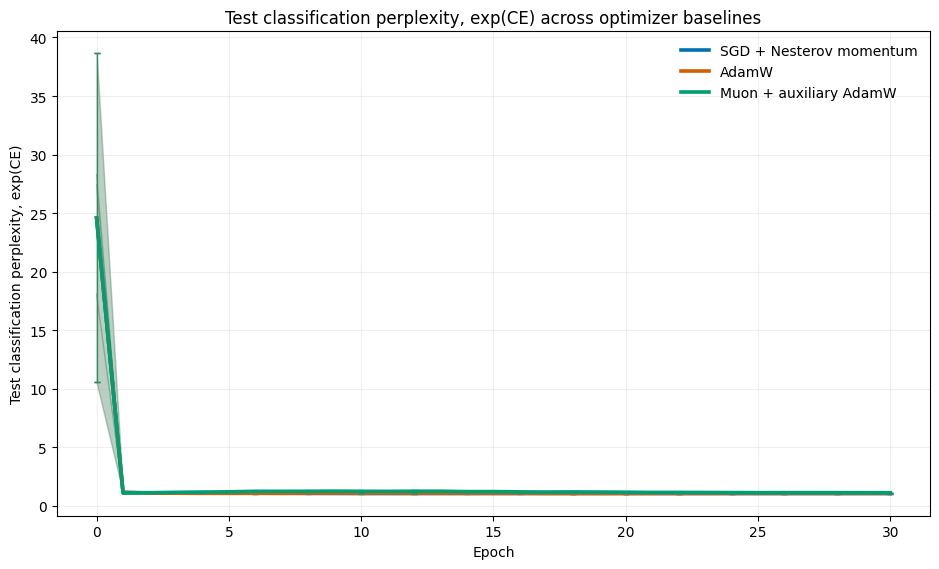

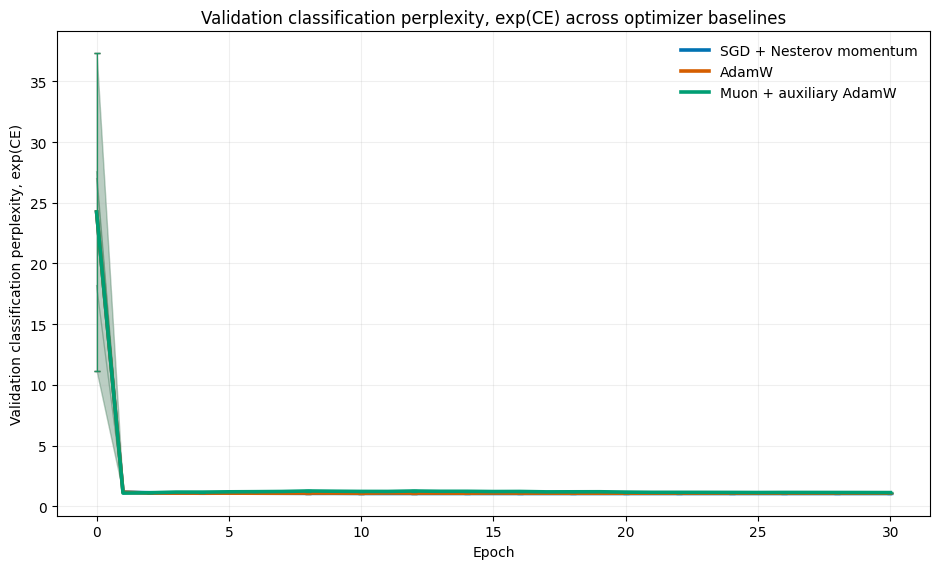

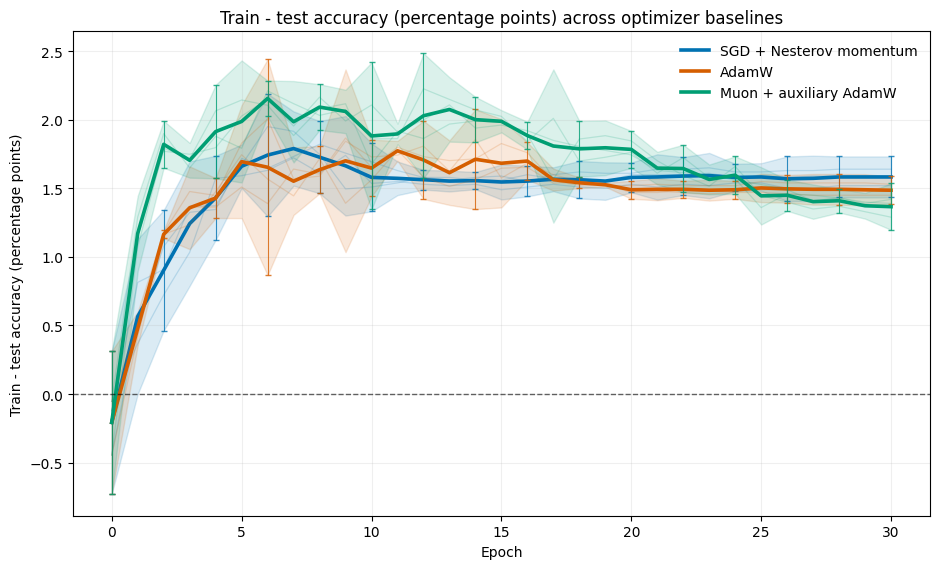

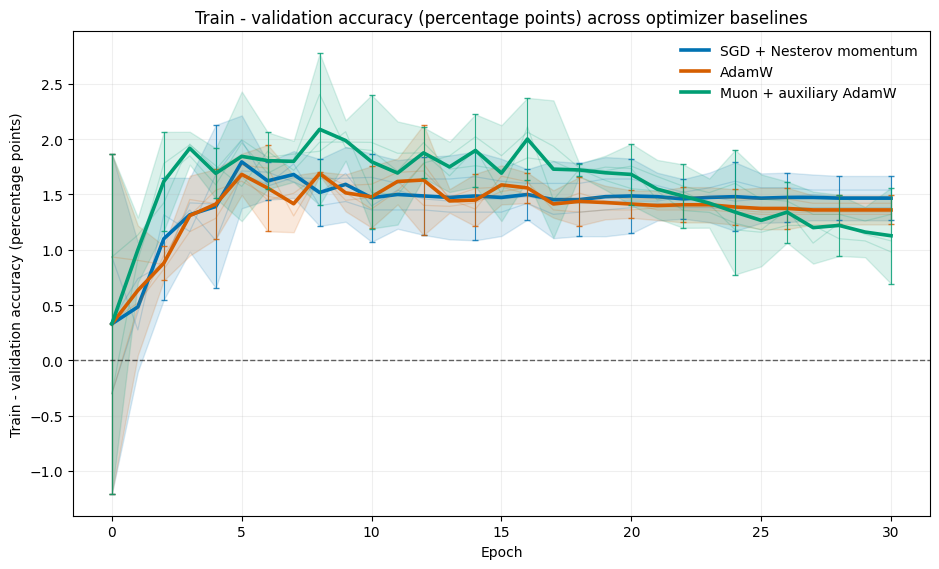

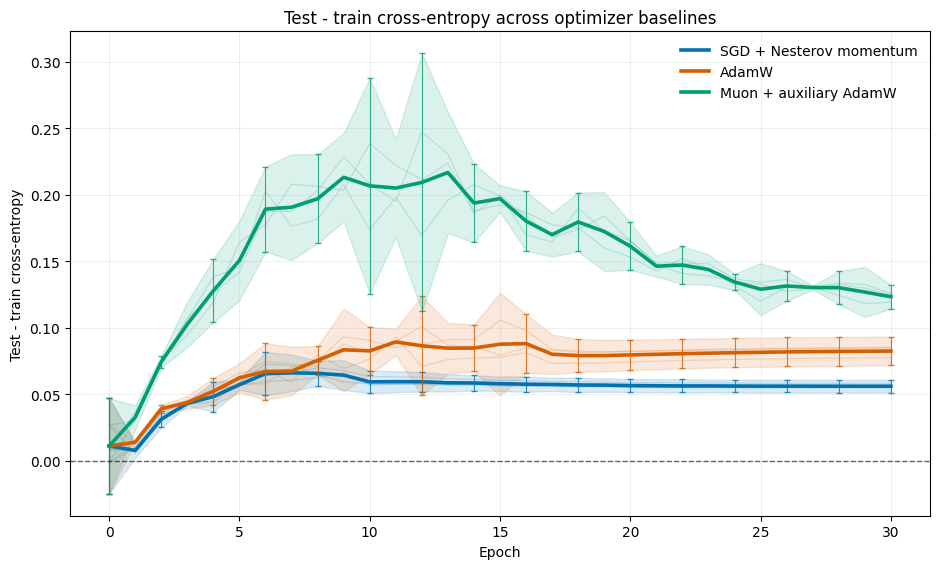

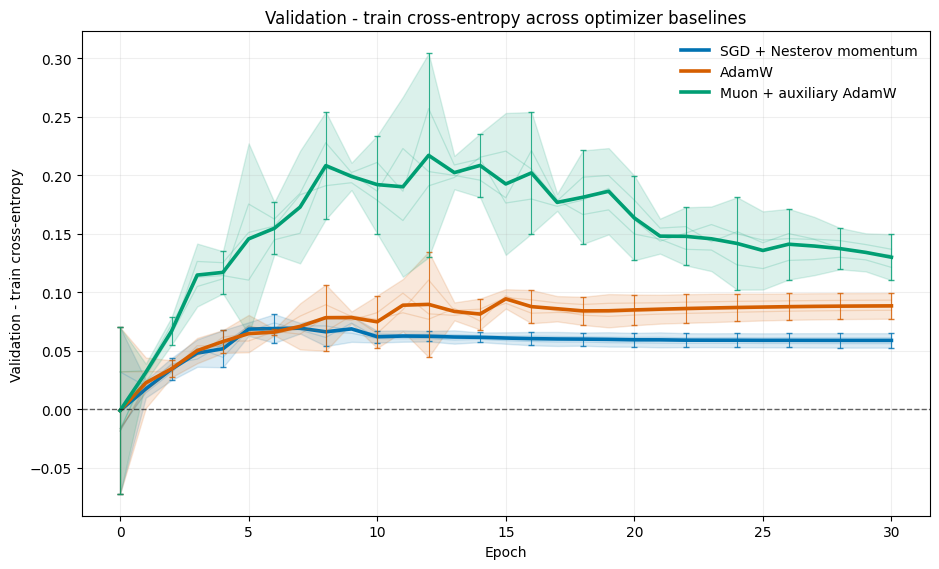

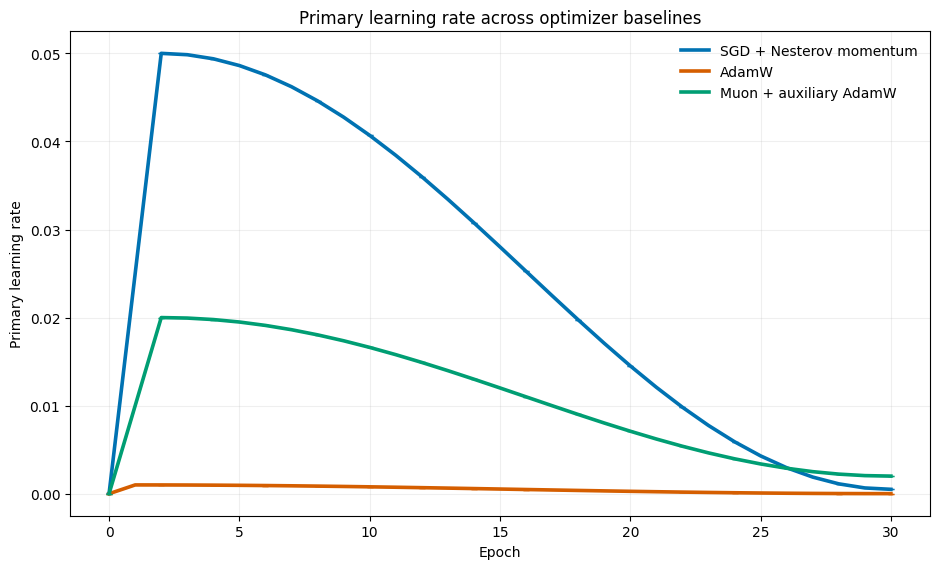

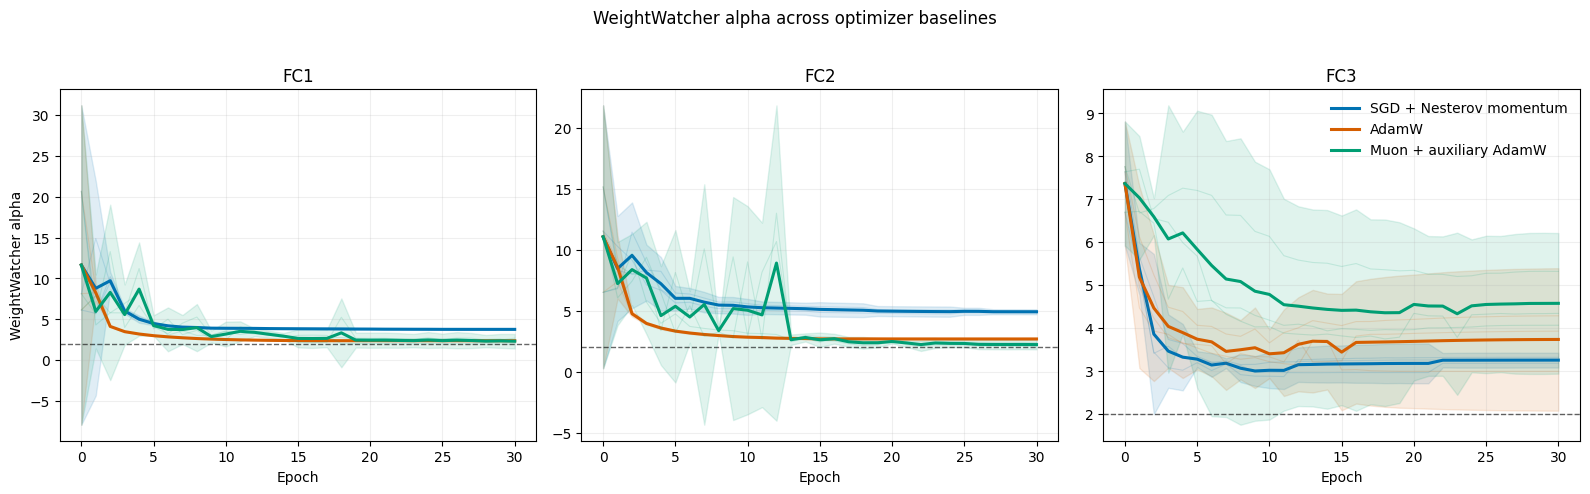

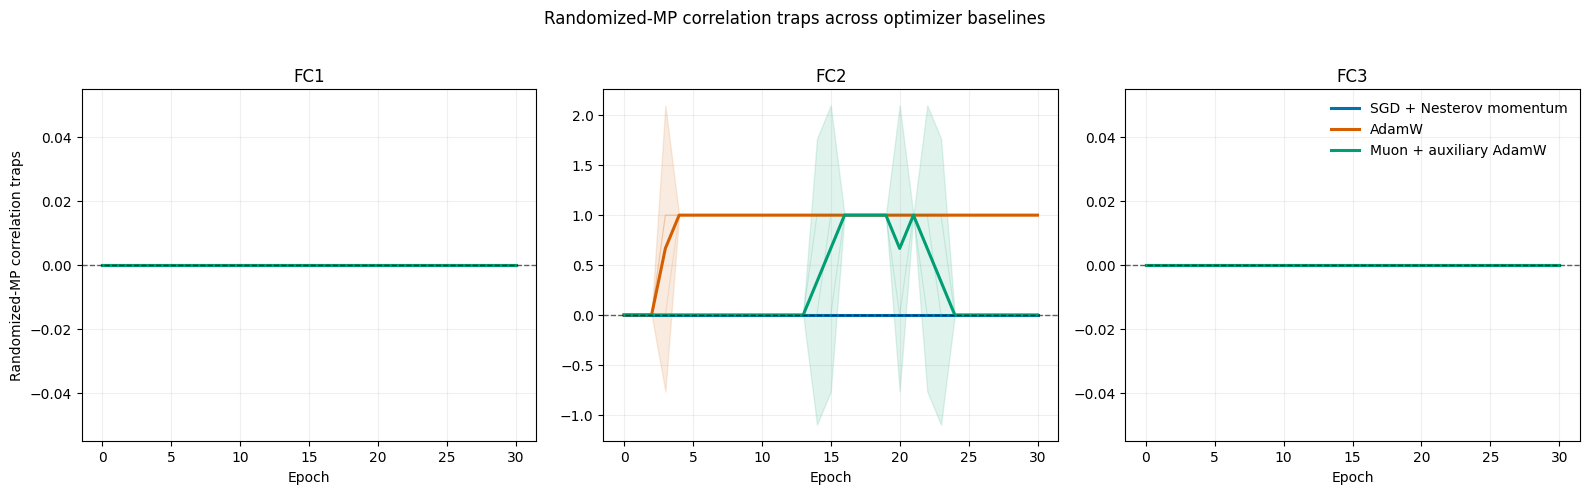

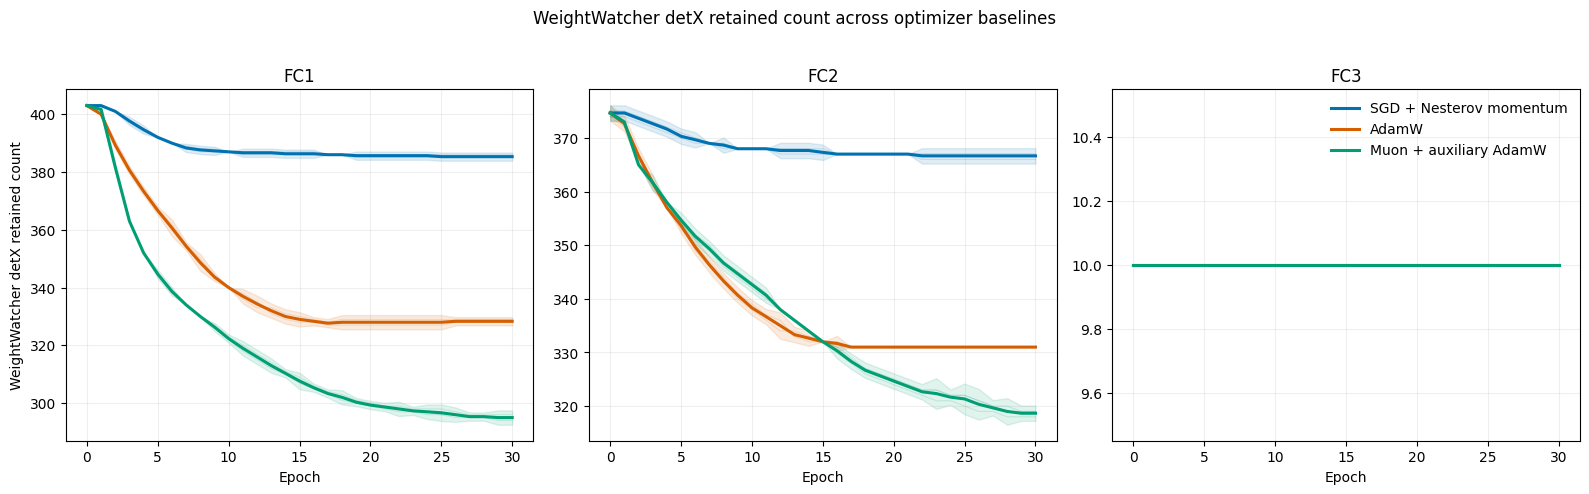

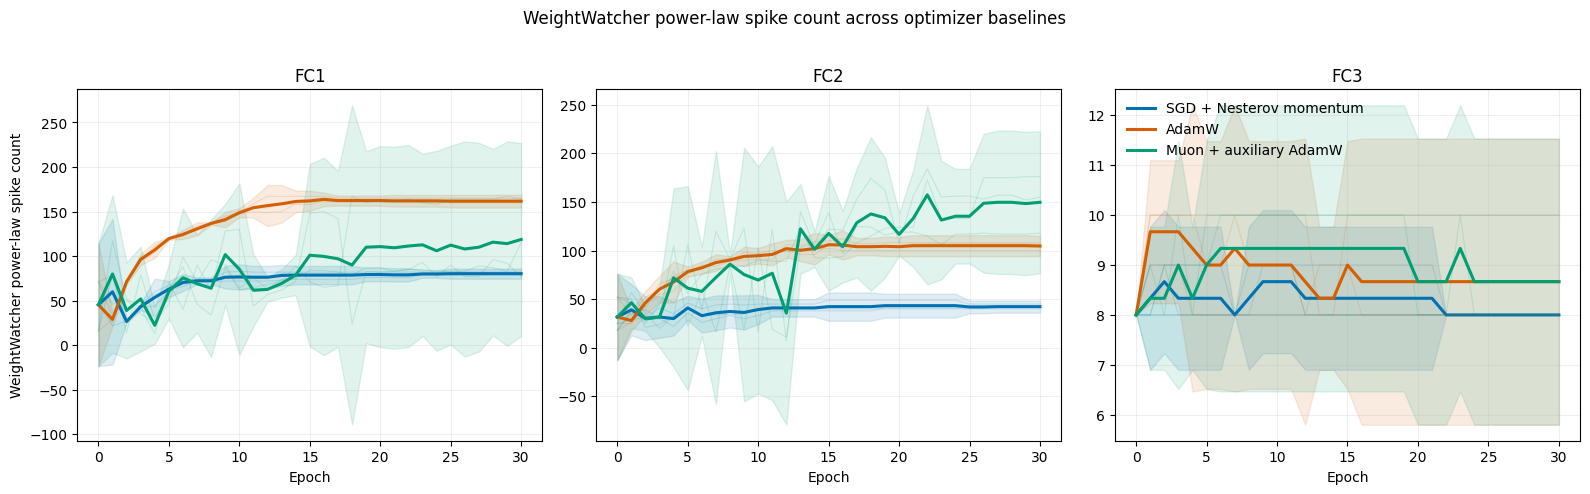

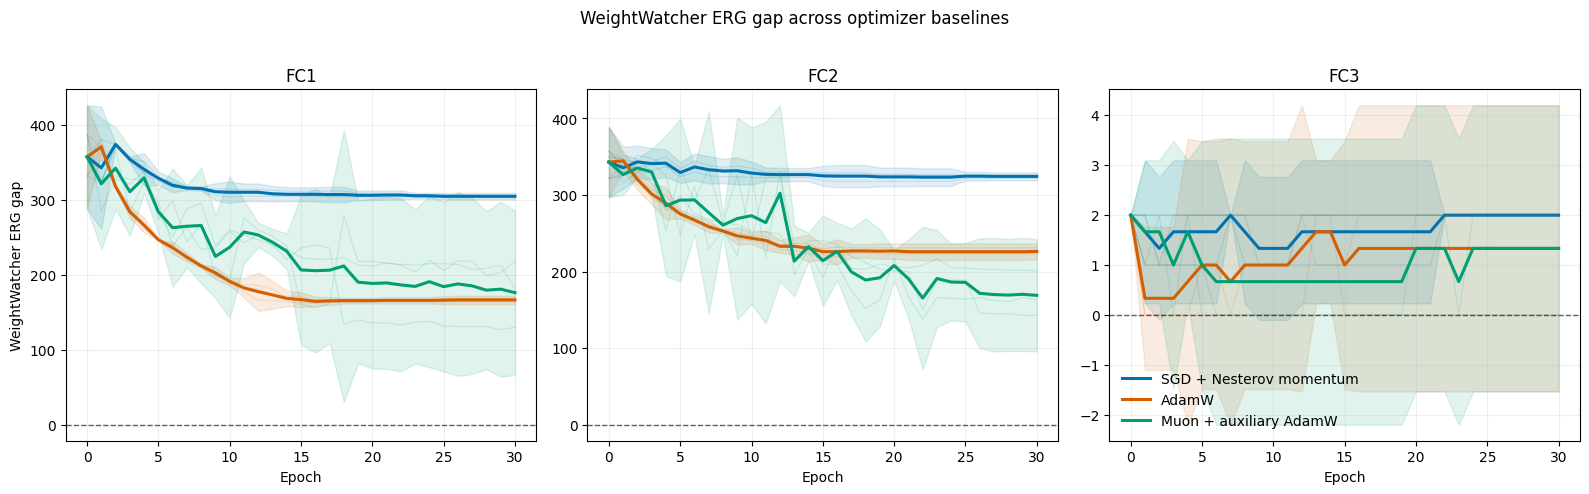

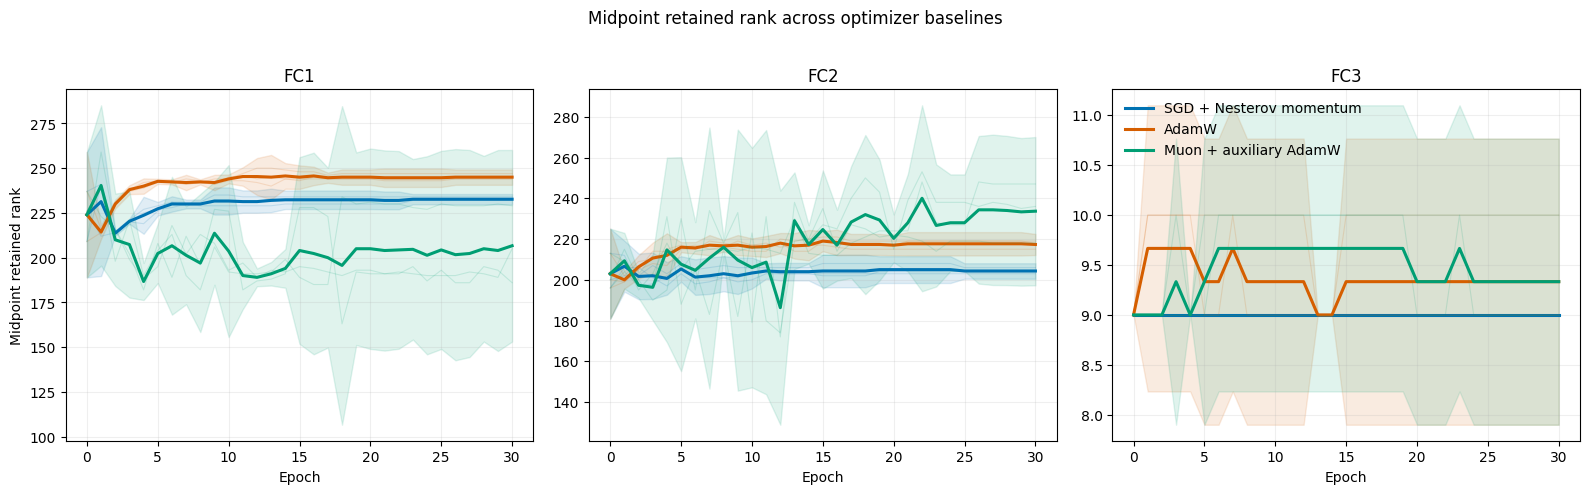

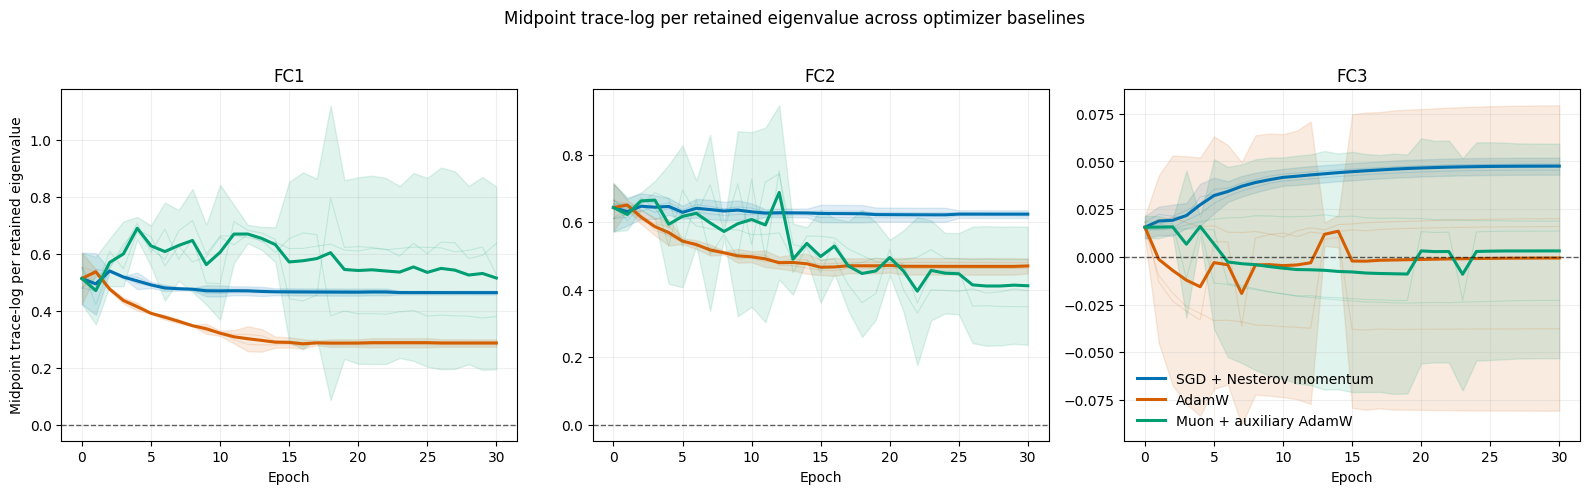

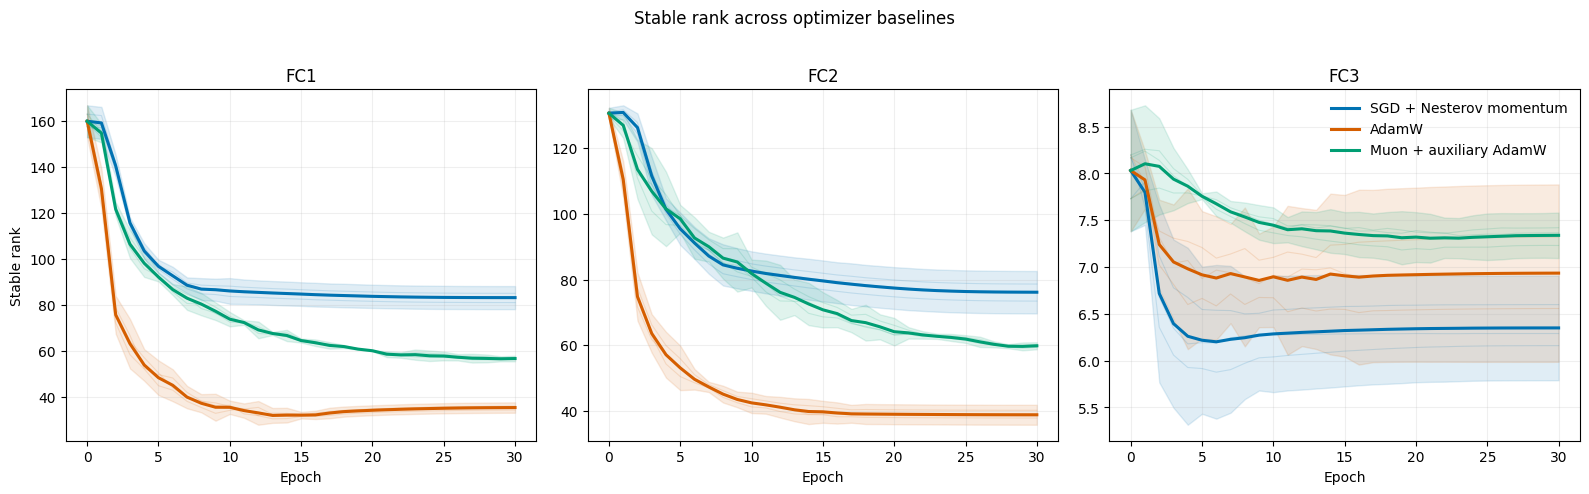

comparison outputs: /private/tmp/rg_optimizers/baseline/notebooks/runs/mnist_mlp3_recipe_v3/comparison


In [2]:
result = run_baseline_comparison(
    RUN_ROOT,
    output_dir=OUTPUT_DIR,
    show_plots=True,
)
assert len(result.seeds) == 3
assert result.epochs == 30
for optimizer, manifest in result.manifests.items():
    config = manifest['config_template']
    assert config['recipe_version'] == MNIST_REFERENCE_RECIPE_VERSION
    assert config['initialization'] == MNIST_REFERENCE_INITIALIZATION
print('comparison outputs:', OUTPUT_DIR)


## Final and validation-selected performance

The validation-selected table evaluates the protected test set only after the checkpoint epoch has been chosen from validation loss.


In [3]:
display(
    result.terminal_by_seed.sort_values(
        ['checkpoint', 'optimizer_label', 'seed']
    )
)
display(
    result.terminal_summary.sort_values(
        ['metric', 'checkpoint', 'optimizer_label']
    )
)
assert result.terminal_summary['n'].eq(3).all()


,run,optimizer,epoch,global_step,primary_lr,auxiliary_lr,train_loss,train_accuracy,train_examples_evaluated,validation_loss,...,weightwatcher_time_sec,epoch_total_time_sec,device,seed,replicate,optimizer_label,train_perplexity,validation_perplexity,test_perplexity,checkpoint
0,AdamW,adamw,30,12900,0.000010,NaN,1.468589e-05,1.000000,55000,0.087420,...,2.531176,11.519786,mps,1337,0,AdamW,1.000015,1.091355,1.080641,final
2,AdamW,adamw,30,12900,0.000010,NaN,1.581340e-05,1.000000,55000,0.084746,...,2.700541,11.821437,mps,2027,1,AdamW,1.000016,1.088440,1.088462,final
4,AdamW,adamw,30,12900,0.000010,NaN,1.408119e-05,1.000000,55000,0.093397,...,7.431150,16.488505,mps,31415,2,AdamW,1.000014,1.097897,1.089100,final
12,Muon + auxiliary AdamW,sgd_momentum_muon,30,12900,0.002000,0.00003,3.467906e-11,1.000000,55000,0.136876,...,2.612202,14.233390,mps,1337,0,Muon + auxiliary AdamW,1.000000,1.146686,1.133191,final
14,Muon + auxiliary AdamW,sgd_momentum_muon,30,12900,0.002000,0.00003,8.019533e-11,1.000000,55000,0.121383,...,3.317289,15.716633,mps,2027,1,Muon + auxiliary AdamW,1.000000,1.129058,1.134090,final
16,Muon + auxiliary AdamW,sgd_momentum_muon,30,12900,0.002000,0.00003,6.068835e-11,1.000000,55000,0.131954,...,3.464090,16.968123,mps,31415,2,Muon + auxiliary AdamW,1.000000,1.141056,1.126674,final
6,SGD + Nesterov momentum,sgd_momentum,30,12900,0.000500,NaN,6.801713e-04,1.000000,55000,0.061781,...,3.660399,12.539553,mps,1337,0,SGD + Nesterov momentum,1.000680,1.063729,1.060808,final
8,SGD + Nesterov momentum,sgd_momentum,30,12900,0.000500,NaN,6.902663e-04,1.000000,55000,0.060265,...,2.583035,11.550472,mps,2027,1,SGD + Nesterov momentum,1.000691,1.062118,1.057120,final
10,SGD + Nesterov momentum,sgd_momentum,30,12900,0.000500,NaN,6.679502e-04,1.000000,55000,0.056884,...,3.166980,12.770719,mps,31415,2,SGD + Nesterov momentum,1.000668,1.058533,1.057530,final
1,AdamW,adamw,7,3010,0.000899,NaN,1.355872e-02,0.995255,55000,0.077829,...,2.870816,12.233010,mps,1337,0,AdamW,1.013651,1.080937,1.075384,validation_selected


,optimizer,optimizer_label,checkpoint,metric,n,mean,std,sem,confidence,critical_value,ci_half_width,ci_low,ci_high,minimum,maximum
19,adamw,AdamW,final,epoch_total_time_sec,3,13.276576,2.785698,1.608323,0.95,4.302653,6.920057,6.356518,20.196633,11.519786,16.488505
99,sgd_momentum_muon,Muon + auxiliary AdamW,final,epoch_total_time_sec,3,15.639382,1.369002,0.790394,0.95,4.302653,3.400790,12.238592,19.040172,14.233390,16.968123
59,sgd_momentum,SGD + Nesterov momentum,final,epoch_total_time_sec,3,12.286915,0.648167,0.374220,0.95,4.302653,1.610137,10.676778,13.897051,11.550472,12.770719
39,adamw,AdamW,validation_selected,epoch_total_time_sec,3,12.244494,0.332706,0.192088,0.95,4.302653,0.826487,11.418007,13.070980,11.917679,12.582793
119,sgd_momentum_muon,Muon + auxiliary AdamW,validation_selected,epoch_total_time_sec,3,15.959524,1.418347,0.818883,0.95,4.302653,3.523370,12.436154,19.482894,14.322369,16.816862
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,sgd_momentum_muon,Muon + auxiliary AdamW,final,weightwatcher_time_sec,3,3.131194,0.455414,0.262933,0.95,4.302653,1.131312,1.999882,4.262505,2.612202,3.464090
58,sgd_momentum,SGD + Nesterov momentum,final,weightwatcher_time_sec,3,3.136805,0.539315,0.311374,0.95,4.302653,1.339733,1.797072,4.476538,2.583035,3.660399
38,adamw,AdamW,validation_selected,weightwatcher_time_sec,3,2.964877,0.272654,0.157417,0.95,4.302653,0.677311,2.287566,3.642189,2.751707,3.272110
118,sgd_momentum_muon,Muon + auxiliary AdamW,validation_selected,weightwatcher_time_sec,3,3.343169,0.611172,0.352860,0.95,4.302653,1.518236,1.824934,4.861405,2.675190,3.874349


## Validation convergence and matched-seed contrasts

Convergence thresholds are defined on validation accuracy. Paired differences are reported for both final and validation-selected checkpoints.


In [4]:
display(result.convergence_by_seed.sort_values(['optimizer_label', 'seed']))
display(result.convergence_summary.sort_values(['metric', 'optimizer_label']))
display(
    result.paired_final_differences.sort_values(
        ['checkpoint', 'metric', 'contrast']
    )
)


,optimizer,optimizer_label,seed,best_validation_loss,best_validation_epoch,validation_selected_test_accuracy,validation_selected_test_loss,final_test_accuracy,final_test_loss,epoch_to_validation_accuracy_0.90,epoch_to_validation_accuracy_0.95,epoch_to_validation_accuracy_0.97,epoch_to_validation_accuracy_0.98
3,adamw,AdamW,1337,0.077829,7,0.9808,0.072678,0.9852,0.077554,1.0,2.0,4.0,7.0
4,adamw,AdamW,2027,0.078772,3,0.9762,0.078702,0.9855,0.084766,1.0,1.0,2.0,6.0
5,adamw,AdamW,31415,0.072267,10,0.9804,0.088287,0.9847,0.085351,1.0,1.0,2.0,7.0
6,sgd_momentum_muon,Muon + auxiliary AdamW,1337,0.090952,1,0.9734,0.088296,0.9871,0.125038,1.0,1.0,1.0,10.0
7,sgd_momentum_muon,Muon + auxiliary AdamW,2027,0.090363,1,0.9714,0.093771,0.9858,0.125831,1.0,1.0,1.0,15.0
8,sgd_momentum_muon,Muon + auxiliary AdamW,31415,0.091120,1,0.9704,0.093823,0.9861,0.119270,1.0,1.0,1.0,13.0
0,sgd_momentum,SGD + Nesterov momentum,1337,0.061764,25,0.9841,0.059087,0.9841,0.059031,1.0,1.0,3.0,6.0
1,sgd_momentum,SGD + Nesterov momentum,2027,0.060265,30,0.9848,0.055548,0.9848,0.055548,1.0,2.0,3.0,7.0
2,sgd_momentum,SGD + Nesterov momentum,31415,0.056884,30,0.9836,0.055936,0.9836,0.055936,1.0,1.0,3.0,7.0


,optimizer,optimizer_label,metric,n,mean,std,sem,confidence,critical_value,ci_half_width,ci_low,ci_high,minimum,maximum
1,adamw,AdamW,best_validation_epoch,3,6.666667,3.511885,2.027588,0.95,4.302653,8.724005,-2.057338,15.390672,3.000000,10.000000
21,sgd_momentum_muon,Muon + auxiliary AdamW,best_validation_epoch,3,1.000000,0.000000,0.000000,0.95,4.302653,0.000000,1.000000,1.000000,1.000000,1.000000
11,sgd_momentum,SGD + Nesterov momentum,best_validation_epoch,3,28.333333,2.886751,1.666667,0.95,4.302653,7.171088,21.162245,35.504421,25.000000,30.000000
0,adamw,AdamW,best_validation_loss,3,0.076289,0.003515,0.002029,0.95,4.302653,0.008732,0.067558,0.085021,0.072267,0.078772
20,sgd_momentum_muon,Muon + auxiliary AdamW,best_validation_loss,3,0.090812,0.000398,0.000230,0.95,4.302653,0.000988,0.089824,0.091800,0.090363,0.091120
10,sgd_momentum,SGD + Nesterov momentum,best_validation_loss,3,0.059637,0.002500,0.001443,0.95,4.302653,0.006210,0.053427,0.065847,0.056884,0.061764
6,adamw,AdamW,epoch_to_validation_accuracy_0.90,3,1.000000,0.000000,0.000000,0.95,4.302653,0.000000,1.000000,1.000000,1.000000,1.000000
26,sgd_momentum_muon,Muon + auxiliary AdamW,epoch_to_validation_accuracy_0.90,3,1.000000,0.000000,0.000000,0.95,4.302653,0.000000,1.000000,1.000000,1.000000,1.000000
16,sgd_momentum,SGD + Nesterov momentum,epoch_to_validation_accuracy_0.90,3,1.000000,0.000000,0.000000,0.95,4.302653,0.000000,1.000000,1.000000,1.000000,1.000000
7,adamw,AdamW,epoch_to_validation_accuracy_0.95,3,1.333333,0.577350,0.333333,0.95,4.302653,1.434218,-0.100884,2.767551,1.000000,2.000000


,checkpoint,optimizer_a,optimizer_b,contrast,metric,n,mean_difference,std_difference,sem_difference,ci_half_width,ci_low,ci_high
0,final,adamw,sgd_momentum,AdamW - SGD + Nesterov momentum,test_accuracy,3,0.000967,2.309401e-04,1.333333e-04,0.000574,0.000393,0.001540
16,final,sgd_momentum_muon,adamw,Muon + auxiliary AdamW - AdamW,test_accuracy,3,0.001200,8.185353e-04,4.725816e-04,0.002033,-0.000833,0.003233
8,final,sgd_momentum_muon,sgd_momentum,Muon + auxiliary AdamW - SGD + Nesterov momentum,test_accuracy,3,0.002167,1.040833e-03,6.009252e-04,0.002586,-0.000419,0.004752
6,final,adamw,sgd_momentum,AdamW - SGD + Nesterov momentum,test_accuracy_gap,3,-0.000967,2.309401e-04,1.333333e-04,0.000574,-0.001540,-0.000393
22,final,sgd_momentum_muon,adamw,Muon + auxiliary AdamW - AdamW,test_accuracy_gap,3,-0.001200,8.185353e-04,4.725816e-04,0.002033,-0.003233,0.000833
14,final,sgd_momentum_muon,sgd_momentum,Muon + auxiliary AdamW - SGD + Nesterov momentum,test_accuracy_gap,3,-0.002167,1.040833e-03,6.009252e-04,0.002586,-0.004752,0.000419
1,final,adamw,sgd_momentum,AdamW - SGD + Nesterov momentum,test_loss,3,0.025719,6.232311e-03,3.598227e-03,0.015482,0.010237,0.041201
17,final,sgd_momentum_muon,adamw,Muon + auxiliary AdamW - AdamW,test_loss,3,0.040822,6.785732e-03,3.917744e-03,0.016857,0.023966,0.057679
9,final,sgd_momentum_muon,sgd_momentum,Muon + auxiliary AdamW - SGD + Nesterov momentum,test_loss,3,0.066541,3.504816e-03,2.023506e-03,0.008706,0.057835,0.075248
7,final,adamw,sgd_momentum,AdamW - SGD + Nesterov momentum,test_loss_gap,3,0.026384,6.231391e-03,3.597695e-03,0.015480,0.010904,0.041863


## Layerwise WeightWatcher summary

`alpha`, `ERG_gap`, and randomized-MP `num_traps` are direct WeightWatcher outputs. Each layer is summarized across the three complete runs; layers are not treated as additional replicates.


In [5]:
spectral = result.spectral_summary[
    result.spectral_summary['metric'].isin([
        'alpha', 'ERG_gap', 'num_traps',
        'm_midpoint', 'trace_log_midpoint_per_eval',
    ])
].sort_values(['metric', 'optimizer_label', 'layer', 'epoch'])
assert spectral['n'].eq(3).all()
display(spectral)


,optimizer,optimizer_label,layer,epoch,metric,n,mean,std,sem,confidence,critical_value,ci_half_width,ci_low,ci_high,minimum,maximum
4,adamw,AdamW,fc1,0,ERG_gap,3,357.666667,27.682726,15.982629,0.95,4.302653,68.767704,288.898962,426.434371,332.000000,387.000000
24,adamw,AdamW,fc1,1,ERG_gap,3,371.000000,3.000000,1.732051,0.95,4.302653,7.452413,363.547587,378.452413,368.000000,374.000000
44,adamw,AdamW,fc1,2,ERG_gap,3,318.000000,1.000000,0.577350,0.95,4.302653,2.484138,315.515862,320.484138,317.000000,319.000000
64,adamw,AdamW,fc1,3,ERG_gap,3,284.333333,3.055050,1.763834,0.95,4.302653,7.589166,276.744167,291.922499,281.000000,287.000000
84,adamw,AdamW,fc1,4,ERG_gap,3,266.333333,4.041452,2.333333,0.95,4.302653,10.039523,256.293810,276.372856,262.000000,270.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3626,sgd_momentum,SGD + Nesterov momentum,fc3,26,trace_log_midpoint_per_eval,3,0.047435,0.001806,0.001043,0.95,4.302653,0.004486,0.042948,0.051921,0.045350,0.048502
3646,sgd_momentum,SGD + Nesterov momentum,fc3,27,trace_log_midpoint_per_eval,3,0.047478,0.001806,0.001043,0.95,4.302653,0.004487,0.042991,0.051965,0.045393,0.048554
3666,sgd_momentum,SGD + Nesterov momentum,fc3,28,trace_log_midpoint_per_eval,3,0.047504,0.001806,0.001043,0.95,4.302653,0.004487,0.043017,0.051992,0.045419,0.048584
3686,sgd_momentum,SGD + Nesterov momentum,fc3,29,trace_log_midpoint_per_eval,3,0.047520,0.001806,0.001043,0.95,4.302653,0.004487,0.043032,0.052007,0.045434,0.048601


The historical result-directory key `sgd_momentum_muon` is retained only for compatibility. Its implementation and label are **Muon + auxiliary AdamW**. No test metric is used for learning-rate choice, checkpoint selection, or stopping.
